In [8]:
import pandas as pd

import matplotlib.pyplot as plt

import numpy as np

In [9]:
customer_ordered = pd.read_csv('/Users/aaronnadler/Downloads/customer_ordered_most.csv')

payment_methods = pd.read_csv('/Users/aaronnadler/Downloads/payment_methods.csv')

most_ordered = pd.read_csv('/Users/aaronnadler/Downloads/most_ordered.csv')

status_percent = pd.read_csv('/Users/aaronnadler/Downloads/most_ordered.csv')

no_orders = pd.read_csv('/Users/aaronnadler/Downloads/no_orders.csv')

best_category = pd.read_csv('/Users/aaronnadler/Downloads/best_category.csv')

total_orders_month = pd.read_csv('/Users/aaronnadler/Downloads/total_orders_month.csv')

customer_spend = pd.read_csv('/Users/aaronnadler/Downloads/customer_spend.csv')

best_selling_prod =pd.read_csv('/Users/aaronnadler/Downloads/best_selling_prod.csv')

total_rev_country = pd.read_csv('/Users/aaronnadler/Downloads/total_rev_by_country.csv')

canceled = pd.read_csv('/Users/aaronnadler/Downloads/cancelledVCompleted.csv')

In [10]:
payment_methods

,total_orders,payment_method
0,446,Credit Card
1,280,Apple Pay
2,238,PayPal
3,236,Debit Card


In [11]:
no_orders

,first_name,last_name
0,Megan,Wilson
1,Michael,Walsh


In [12]:
best_selling_prod

,product_name,best_product
0,Gaming Laptop X7,245998.36
1,UltraSlim 13 Laptop,167998.60
2,ProBook 15 Laptop,132298.53
3,Nova Phone Pro,102398.72
4,Pixel Max 6,94498.65


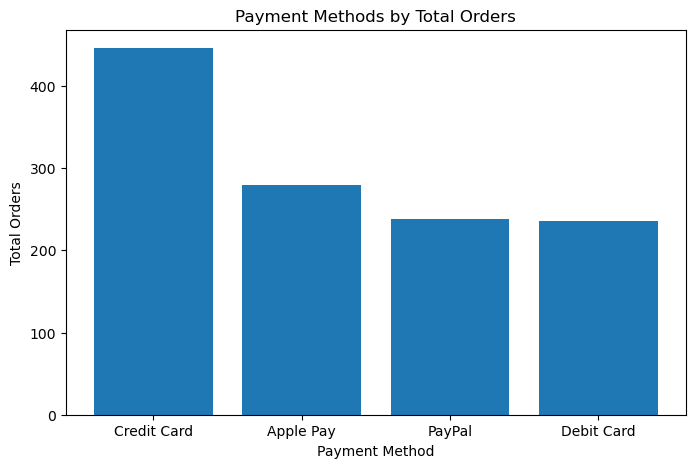

In [21]:
plt.figure(figsize = (8,5))

plt.bar(payment_methods['payment_method'], (payment_methods['total_orders']))

plt.title('Payment Methods by Total Orders')
        
plt.xlabel('Payment Method')
plt.ylabel('Total Orders')
plt.show()

## Payment Methods by Total Orders

**SQL Query:**
```sql
SELECT COUNT(order_id) AS total_orders, payment_method 
FROM orders
GROUP BY payment_method
ORDER BY total_orders DESC;
```

In [24]:
total_rev_country

,country,total_revenue
0,Ireland,356445.37
1,Germany,236350.86
2,USA,401151.72
3,UK,355763.08
4,Netherlands,106072.61
5,France,77096.06


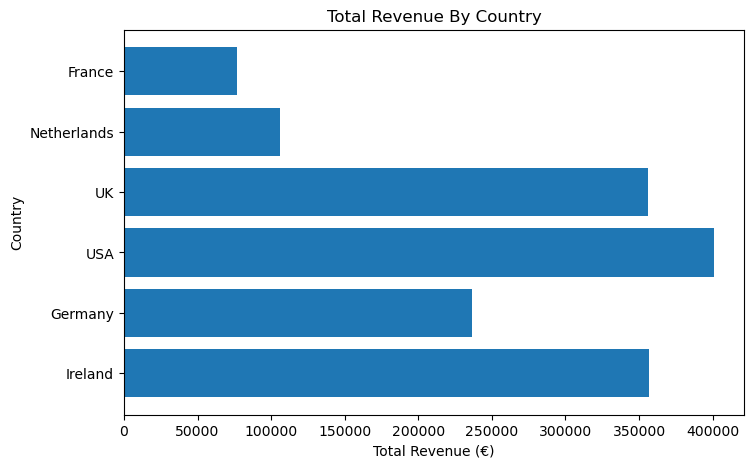

In [69]:
plt.figure(figsize = (8,5))

plt.barh(total_rev_country['country'], (total_rev_country)['total_revenue'])
plt.title('Total Revenue By Country')
plt.xlabel('Total Revenue (€)')
plt.ylabel('Country')
plt.show()

## Total Revenue by Country

**SQL Query:**
```sql
SELECT customers.country, SUM(unit_price * quantity) AS total_revenue
FROM orders
LEFT JOIN customers ON customers.customer_id = orders.customer_id
LEFT JOIN order_items ON order_items.order_id = orders.order_id
GROUP BY customers.country;
```

In [31]:
customer_ordered

,first_name,last_name,total_orders
0,Leah,Quinn,14
1,Niamh,White,13
2,Aaron,Fitzgerald,11
3,Olivia,Collins,11
4,Laura,Evans,10
5,Sinead,Farrell,10
6,Michael,Byrne,10
7,Paul,Thompson,10
8,David,McCarthy,10
9,Laura,Murphy,9


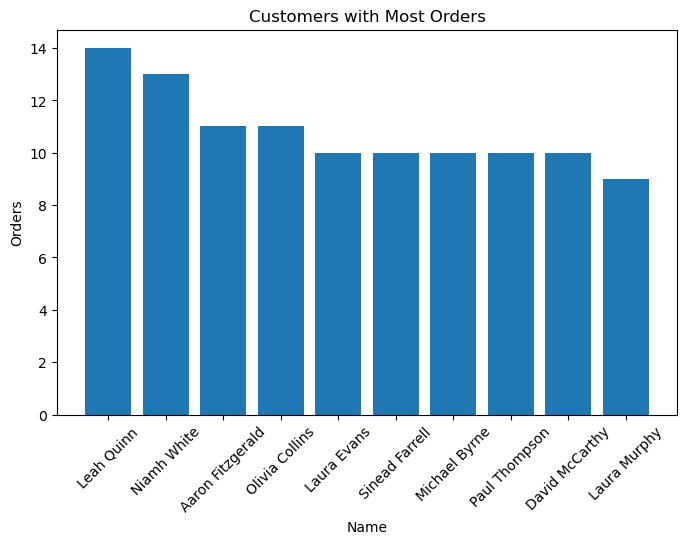

In [47]:
customer_ordered['full_name'] = customer_ordered['first_name'] + ' ' + customer_ordered['last_name']

plt.figure(figsize=(8, 5))
plt.bar(customer_ordered['full_name'], customer_ordered['total_orders'])
plt.title("Customers with Most Orders")
plt.ylabel('Orders')
plt.xlabel('Name')
plt.xticks(rotation=45)

plt.show()

In [51]:
percent_status=pd.read_csv('/Users/aaronnadler/Downloads/percent_status.csv')

In [52]:
percent_status

,status,total,percent
0,Completed,474,39.5
1,Refunded,160,13.3
2,Processing,202,16.8
3,Shipped,189,15.8
4,Cancelled,175,14.6


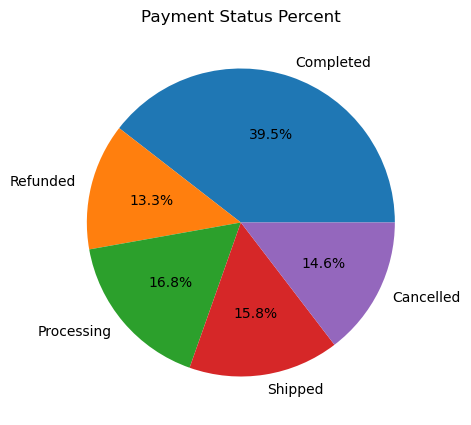

In [56]:
plt.figure(figsize=(8,5))
plt.pie(percent_status['percent'], labels=percent_status['status'],autopct='%1.1f%%')
plt.title('Payment Status Percent')
plt.show()

## Order Status Breakdown

**SQL Query:**
```sql
SELECT status, COUNT(*) AS total,
ROUND(COUNT(*) * 100 / (SELECT COUNT(*) FROM orders), 1) AS percent
FROM orders
GROUP BY status;
```

In [57]:
best_selling_prod

,product_name,best_product
0,Gaming Laptop X7,245998.36
1,UltraSlim 13 Laptop,167998.60
2,ProBook 15 Laptop,132298.53
3,Nova Phone Pro,102398.72
4,Pixel Max 6,94498.65


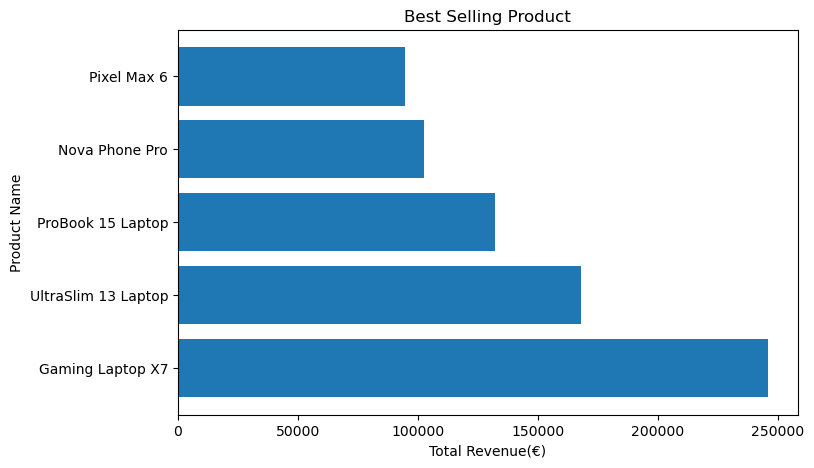

In [68]:
plt.figure(figsize=(8,5))
plt.barh(best_selling_prod['product_name'],(best_selling_prod)['best_product'])
plt.title('Best Selling Product')
plt.xlabel("Total Revenue(€)")
plt.ylabel("Product Name")
plt.show()

In [60]:
most_ordered

,product_name,times_ordered,total_revenue
0,Office Desk 120cm,93,45498.18
1,Moisturiser SPF50,92,4623.15
2,Knit Cardigan,91,8323.15
3,Resistance Band Set,91,4573.17
4,Nova Phone Lite,91,70398.24


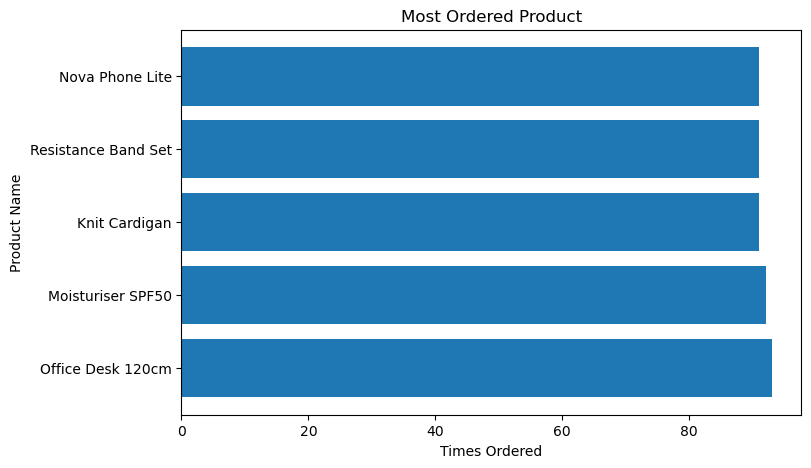

In [61]:
plt.figure(figsize=(8,5))
plt.barh(most_ordered['product_name'],(most_ordered)['times_ordered'])
plt.title('Most Ordered Product')
plt.xlabel("Times Ordered")
plt.ylabel("Product Name")
plt.show()

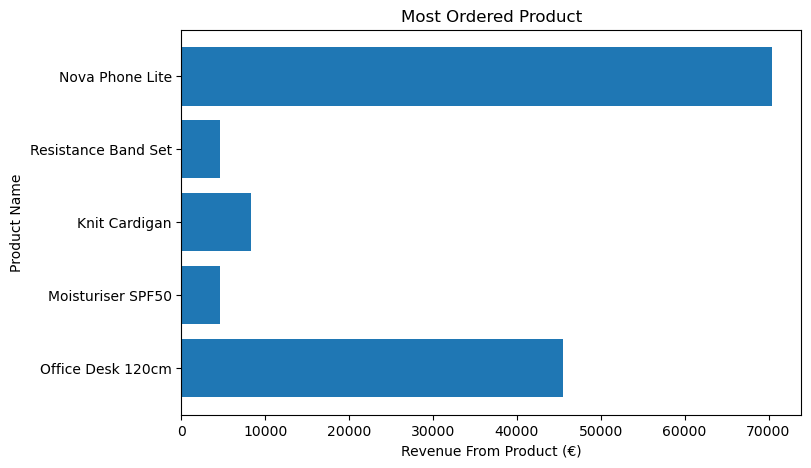

In [67]:
plt.figure(figsize=(8,5))
plt.barh(most_ordered['product_name'],(most_ordered)['total_revenue'])
plt.title('Most Ordered Product')
plt.xlabel("Revenue From Product (€)")
plt.ylabel("Product Name")
plt.show()

## Most Ordered Products

**SQL Query:**
```sql
SELECT product_name, COUNT(product_name) AS times_ordered, 
SUM(quantity * unit_price) AS total_revenue
FROM products
JOIN order_items ON order_items.product_id = products.product_id
GROUP BY product_name
ORDER BY times_ordered DESC
LIMIT 5;
```

In [63]:
best_category

,department,best_category
0,Electronics,1221566.99
1,Home,158741.26
2,Fashion,106461.42
3,Sports,21340.39
4,Beauty,16008.86


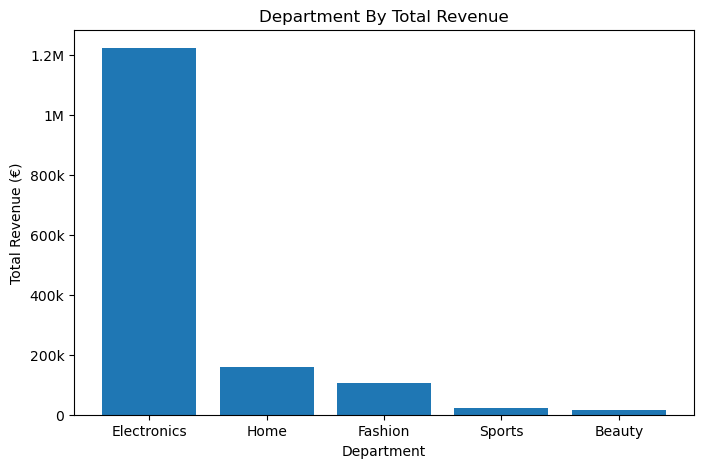

In [66]:
plt.figure(figsize=(8,5))
plt.bar(best_category['department'], (best_category['best_category']))

plt.title("Department By Total Revenue")
plt.xlabel("Department")
plt.ylabel("Total Revenue (€)")
plt.yticks([0, 200000, 400000, 600000, 800000, 1000000, 1200000], 
           ['0', '200k', '400k', '600k', '800k', '1M', '1.2M'])

plt.show()

## Revenue by Department

**SQL Query:**
```sql
SELECT categories.department, SUM(quantity * unit_price) AS total_revenue
FROM products
JOIN categories ON categories.category_id = products.category_id
JOIN order_items ON order_items.product_id = products.product_id
GROUP BY categories.department
ORDER BY total_revenue DESC
LIMIT 5;
```

In [74]:
avg_margin = pd.read_csv('/Users/aaronnadler/Downloads/avg_margin_percent.csv')
month_rev_growth = pd.read_csv('/Users/aaronnadler/Downloads/month_revenue_growth.csv')
avg_order_value_country = pd.read_csv('/Users/aaronnadler/Downloads/avg_order_value_country.csv')
customer_retention = pd.read_csv('/Users/aaronnadler/Downloads/Customer_retention.csv')

In [75]:
avg_margin

,avg_margin_percent,department
0,75.3,Media
1,70.0,Beauty
2,63.1,Sports
3,60.9,Fashion
4,54.2,Home


Text(0, 0.5, 'Margin (%)')

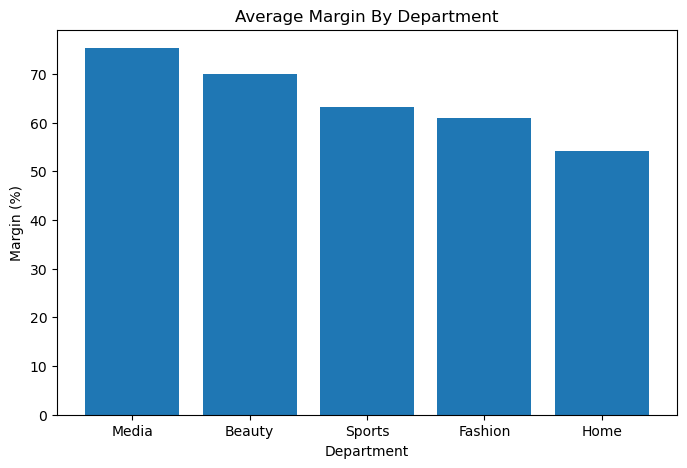

In [79]:
plt.figure(figsize=(8,5))
plt.bar(avg_margin['department'], (avg_margin['avg_margin_percent']))
plt.title("Average Margin By Department")
plt.xlabel('Department')
plt.ylabel('Margin (%)')

## Average Profit Margin by Department

**SQL Query:**
```sql
SELECT ROUND(AVG((price - cost) / price * 100), 1) AS avg_margin_percent, categories.department
FROM products
JOIN categories ON categories.category_id = products.category_id
GROUP BY categories.department
ORDER BY avg_margin_percent DESC
LIMIT 5;
```

In [80]:
month_rev_growth

,month,revenue,prev_month_revenue,growth_percent
0,1,149281.95,NaN,NaN
1,2,142762.19,149281.95,-4.4
2,3,183914.16,142762.19,28.8
3,4,197924.74,183914.16,7.6
4,5,142371.25,197924.74,-28.1
5,6,138959.55,142371.25,-2.4
6,7,113397.73,138959.55,-18.4
7,8,77411.65,113397.73,-31.7
8,9,73164.90,77411.65,-5.5
9,10,101165.73,73164.90,38.3


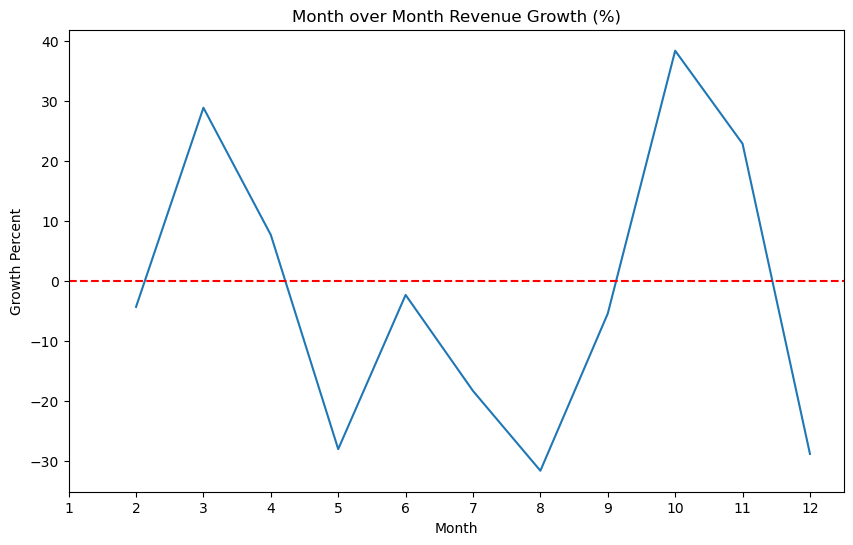

In [82]:
plt.figure(figsize=(10,6))
plt.plot(month_rev_growth['month'],(month_rev_growth['growth_percent']))
plt.title('Month over Month Revenue Growth (%)')
plt.xlabel("Month")
plt.ylabel("Growth Percent")
plt.axhline(y=0, color='red', linestyle='--')
plt.xticks(range(1, 13))

plt.show()

## Month over Month Revenue Growth

**SQL Query:**
```sql
WITH monthly_revenue AS (
    SELECT SUM(quantity * unit_price) AS revenue, MONTH(order_date) AS month 
    FROM orders
    JOIN order_items ON order_items.order_id = orders.order_id
    GROUP BY month
    ORDER BY month
),
with_lag AS (
    SELECT month, revenue,
    LAG(revenue) OVER (ORDER BY month) AS prev_month_revenue
    FROM monthly_revenue
)
SELECT month, revenue, prev_month_revenue,
ROUND((revenue - prev_month_revenue) / prev_month_revenue * 100, 1) AS growth_percent
FROM with_lag;
```

In [83]:
avg_order_value_country

,country,avg_order_value
0,UK,1378.93
1,Netherlands,1359.91
2,USA,1332.73
3,Germany,1277.57
4,France,1204.63
5,Ireland,1135.18


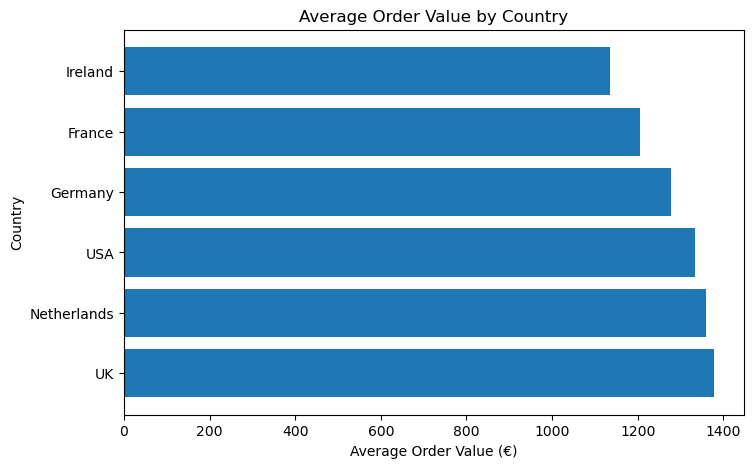

In [88]:
plt.figure(figsize=(8,5))
plt.barh(avg_order_value_country['country'], (avg_order_value_country['avg_order_value']))
plt.title("Average Order Value by Country")
plt.xlabel('Average Order Value (€)')
plt.ylabel('Country')
plt.show()

## Average Order Value by Country

**SQL Query:**
```sql
WITH order_totals AS (
    SELECT orders.order_id, orders.customer_id, SUM(quantity * unit_price) AS order_total
    FROM orders
    JOIN order_items ON order_items.order_id = orders.order_id
    GROUP BY orders.order_id, orders.customer_id
)
SELECT customers.country, ROUND(AVG(order_total), 2) AS avg_order_value
FROM order_totals
JOIN customers ON customers.customer_id = order_totals.customer_id
GROUP BY customers.country
ORDER BY avg_order_value DESC;
```

In [90]:
customer_retention

,customer_type,total_customers
0,Returning,277
1,One Time,21


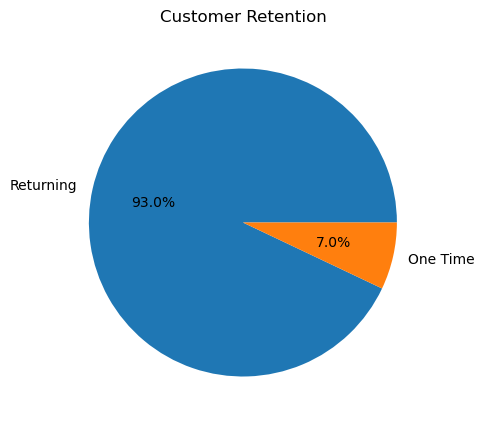

In [91]:
plt.figure(figsize=(8,5))
plt.pie(customer_retention['total_customers'], labels=customer_retention['customer_type'],autopct='%1.1f%%')
plt.title('Customer Retention')
plt.show()

## Customer Retention

**SQL Query:**
```sql
SELECT
CASE
    WHEN total_orders = 1 THEN 'One Time'
    WHEN total_orders > 1 THEN 'Returning'
END AS customer_type,
COUNT(*) AS total_customers
FROM (
    SELECT COUNT(order_id) AS total_orders, customer_id
    FROM orders
    GROUP BY customer_id
) AS order_counts
GROUP BY customer_type;
```